## What you need to know about crystals 
### ...and how to manipulate crystals structures with computers

#### Resources beyond this for learning about crystal structures

Textbooks
* Intro to Solid State Physics by Charles Kittel, specifically Chapters 1 and 2
* Solid State Physics by Neil Ashcroft and David Mermin, specifically Chapters 4 - 7

Some of my lecture slides for formerly 6.730 / now 6.6510 Physics for Solid-State Applications:
* [1D Periodic Structures - slides](https://docs.google.com/presentation/d/185LFU2LNmN8zWLuN9PjLtd94MPje5B6HJrcnxBFSCps/edit?usp=share_link) / [notes](https://www.dropbox.com/s/u9dwnp78sbusyvb/Lecture_4_Notes_Periodic_Lattices_Real_Space_20220207.pdf?dl=0)
* [3D Periodic Structures - slides](https://docs.google.com/presentation/d/1sYFaoOy5ywIk3x0kEwPSyIz6VPcNq269SLVufzXEhGQ/edit?usp=share_link) / [notes](https://www.dropbox.com/s/7saifo1s03g9oov/Lecture_5_Notes_Periodic_Lattices_Reciprocal_Space_20220209.pdf?dl=0)
* [X-ray Diffraction - slides](https://docs.google.com/presentation/d/110EQ9AvCPFAyvawDzxRcjWvNsCNPMQEdV1fUIwxjBks/edit?usp=share_link) / [notes](https://www.dropbox.com/s/fb7csxx3lswi86m/Lecture_6_Notes_Scattering_Xrays_20220211.pdf?dl=0)


#### Advanced Resources
[The International Tables of Crystallography](https://it.iucr.org/)
* An indepth reference on everything to do with crystallography.

[Bilbao Crystallographic Server](https://www.cryst.ehu.es/)
* Many tools for analyzing the symmetry of crystal structures.


## Crystals are spatially periodic. 
They have specific translation symmetries and can have additional rotation symmetries.

Any periodic 3D pattern can be described by 1 of 14 different lattices. These are called the [Bravais lattices](https://en.wikipedia.org/wiki/Bravais_lattice#In_3_dimensions). They are all simply parallelepipeds with distinct symmetry (rotational and translational).

### Because of their different symmetry, Bravais lattices are specified with 1 - 6 parameters.
These parameters correspond to the lengths of the sides of the box ($a$, $b$, $c$) and the angles between the sides ($\alpha$, $\beta$, $\gamma$). The least symmetric Bravais lattice, Triclinic, requires defining all three lengths and all three angles. The most symmetric Bravais lattice, Cubic, only requires that you specify the length of the sides, the angles are all fixed to be 90 degrees.

### To describe a crystal, you have to specify a unit cell (a Bravais lattice with specific parameters) and the locations of atoms in the unit cell.
A unit cell is defined by three unit vectors denoted as ($a$, $b$, $c$) or ($a_1$, $a_2$, $a_3$). The ordering of these vectors is not physical but does carry conventions inherited from crystallography. Typically the 

To describe locations one can use
* Cartesian Coordinates (typically setting a specific corner of the lattice to be the origin (0,0,0))
* Fractional Coordinates -- for example (0.5, 0.5, 0.5) is the coordinate that projects onto half way along each of the unit vectors.

### Unit cells are commonly described in two ways: conventional and primitive cells.
* With a conventional cell, it is easier to see the overall symmetry (especially rotational) of the crystal.
* A primitive unit cell has the smallest volume and contains the least number of atoms needed to describe the infinite 3D periodic pattern.

### There is no unique way to describe a crystal, however there are conventions.
* A unit cell is typically chosen such that the lengths of the unit vectors are minimized.

## The language of crystals is tied to how we measure them using [x-ray crystallography](https://en.wikipedia.org/wiki/X-ray_crystallography)
We characterize crystals not by taking images of them (real space) but by diffracting off of them. This means the pictures we take are in reciprocal space which is the same space as when one computes the Fourier transform of a real space signal. This is also called momentum space in solid state physics classes because observables of position and momenta are conjugate variables and you can always choose to describe your system in one or the other.

To determine a crystal's structure you...
1. Shoot x-rays of a given energy at the crystal, collect diffraction pattern, rotate slowly and repeat.
2. Determine the unit cell (Bravais lattice) from e.g. powder XRD pattern.
3. Determine the space group from the systematic disappearances of Bragg peaks allowed by your Bravais lattice.
4. Determine what atoms are within the unit cell that give rise to that spacegroup.
    * Uses a combination of knowledge about the specific material (e.g. elements and stoichometry) 
    * and prior knowledge of structures with similar patterns.
    * Given a model (i.e. a guess structure) we can compute it's x-ray crystallography pattern.

### [The convolution theorem](https://en.wikipedia.org/wiki/Convolution_theorem)
The Fourier transform of a crystal has two pieces. The Fourier transform of the "box" (Bravais lattice) and the Fourier transform of "what's inside the box" (also called the basis). Because of the convolution theorem -- convolutions in real space are simply multiplication in reciprocal space.

### What makes XRD hard? 
A Fourier transform gives magnitudes and phases, but X-ray diffraction only gives intensities (magnitude squared -- phase is lost). For a great webpage about Fourier transforms and the importance of phases:
* Kevin Cowtan's Picture Book of Fourier Transforms
    * http://www.ysbl.york.ac.uk/~cowtan/fourier/fourier.html

## There are many databases of crystal structures
* [Inorganic Crystal Structure Database](https://icsd.fiz-karlsruhe.de/index.xhtml)
    * Requires a license
* [Crystallography Open Database (COD)](http://www.crystallography.net/cod/)
* [Cambridge Structural Database](https://www.ccdc.cam.ac.uk/solutions/csd-core/components/csd/)
    * This database contains a variety of organic and hybrid structures including [molecular crystals](https://en.wikipedia.org/wiki/Molecular_solid) and [metal-organic frameworks](https://en.wikipedia.org/wiki/Metal%E2%80%93organic_framework).
    * Requires a license. For MIT see [here](https://ist.mit.edu/cambridge-structural-database)
* [Materials Project Database](https://materialsproject.org/)
    * This database is largely derived from DFT relaxations of ICSD structures but has expanded beyond that scope.
* [Open Quantum Materials Database](https://oqmd.org/)
* [NOMAD](https://nomad-lab.eu/services/repo-arch)

## There are many softwares for working with crystal structures

### Python code bases
* [`pymatgen`](https://pymatgen.org/installation.html) and [`mp-api`](https://docs.materialsproject.org/downloading-data/using-the-api/getting-started)
* [`MatMiner`](https://hackingmaterials.lbl.gov/matminer/installation.html)
* `ase`
* `aiida`
* ...

## We're going to use the Materials Project database (`mp-api`) and pymatgen to download and analyze some crystals

In [1]:
from mp_api.client import MPRester
import os

# Assumes you have exported your API key as an environmental variable e.g. in your ~/.bashrc
with MPRester() as mpr:
    # mp-149 is Silicon in the diamond phase (https://materialsproject.org/materials/mp-149)
        # The diamond structure has two symmetrically distinct atoms. It is NOT a Bravais lattice.
    # mp-13 is Iron in the bcc phase (https://materialsproject.org/materials/mp-13)
        # BCC is a Bravais lattice
        # note, for project, want things in Bravais lattice
    si_doc = mpr.materials.search(material_ids=["mp-149"])
    fe_doc = mpr.summary.search(material_ids=["mp-13"])
    # See more about querying data here
    # https://docs.materialsproject.org/downloading-data/using-the-api/querying-data

/Users/elyssahofgard/opt/miniconda3/envs/tda_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Retrieving MaterialsDoc documents: 100%|██████████| 1/1 [00:00<00:00, 1321.04it/s]
/var/folders/sm/dkyyvndj7plgwpxsyyvc9vdm0000gn/T/ipykernel_45788/3685597376.py:12: DeprecationWarning: Accessing summary data through MPRester.summary is deprecated. Please use MPRester.materials.summary instead.
  fe_doc = mpr.summary.search(material_ids=["mp-13"])
Retrieving SummaryDoc documents: 100%|██████████| 1/1 [00:00<00:00, 35848.75it/s]


In [2]:
# tasks are associated with computations that have been done
print(si_doc[0])

MPDataDoc<MaterialsDoc>
builder_meta=EmmetMeta(emmet_version='0.71.0', pymatgen_version='2023.10.4', pull_request=990, database_version='2023.11.1', build_date=datetime.datetime(2023, 10, 18, 21, 30, 3, 258000), license='BY-C'),
nsites=2,
elements=[Element Si],
nelements=1,
composition=Composition('Si2'),
composition_reduced=Composition('Si1'),
formula_pretty='Si',
formula_anonymous='A',
chemsys='Si',
volume=40.32952684741405,
density=2.312800253345134,
density_atomic=20.164763423707026,
symmetry=SymmetryData(crystal_system=<CrystalSystem.cubic: 'Cubic'>, symbol='Fd-3m', number=227, point_group='m-3m', symprec=0.1, version='2.0.2'),
material_id=MPID(mp-149),
structure=Structure Summary
Lattice
    abc : 3.8492784033699095 3.8492794116013456 3.849278
 angles : 60.00001213094421 60.00000346645984 60.00001097545789
 volume : 40.32952684741405
      A : 3.333573 0.0 1.924639
      B : 1.111191 3.142924 1.924639
      C : 0.0 0.0 3.849278
    pbc : True True True
PeriodicSite: Si (3.889, 2.

In [3]:
# Silicon crystal structure
print("Formula: ", si_doc[0].formula_pretty)

Formula:  Si


In [4]:
# Save structure to variable for convenience
# abs are the lengths of the unit cell
# coordinates can either be in xyz space or fractional coordinates (second grouping)
si = si_doc[0].structure
fe = fe_doc[0].structure
si

Structure Summary
Lattice
    abc : 3.8492784033699095 3.8492794116013456 3.849278
 angles : 60.00001213094421 60.00000346645984 60.00001097545789
 volume : 40.32952684741405
      A : 3.333573 0.0 1.924639
      B : 1.111191 3.142924 1.924639
      C : 0.0 0.0 3.849278
    pbc : True True True
PeriodicSite: Si (3.889, 2.75, 6.736) [0.875, 0.875, 0.875]
PeriodicSite: Si (0.5556, 0.3929, 0.9623) [0.125, 0.125, 0.125]

In [5]:
fe

Structure Summary
Lattice
    abc : 2.477813028804854 2.477809133849768 4.054295207189474
 angles : 90.00003845025343 90.00031950636807 109.469836683298
 volume : 23.468168469356993
      A : 2.33614509 0.00011167 -0.82582293
      B : -1.16807798 2.02304724 -0.8260822
      C : 1.17007387 2.027305 3.31032796
    pbc : True True True
PeriodicSite: Fe (1.169, 2.025, 0.8292) [0.5, 0.5, 0.5]
PeriodicSite: Fe (1.168, 2.023, -1.652) [1.0, 1.0, 1e-08]

In [6]:
# Save to symmetrized CIF (note the symprec argument) that we can view in VESTA
si.to(fmt="CIF", filename="si.cif", symprec=1e-2)
fe.to(fmt="CIF", filename="fe.cif", symprec=1e-2)

"# generated using pymatgen\ndata_Fe\n_symmetry_space_group_name_H-M   Im-3m\n_cell_length_a   2.86303550\n_cell_length_b   2.86303550\n_cell_length_c   2.86303550\n_cell_angle_alpha   90.00000000\n_cell_angle_beta   90.00000000\n_cell_angle_gamma   90.00000000\n_symmetry_Int_Tables_number   229\n_chemical_formula_structural   Fe\n_chemical_formula_sum   Fe2\n_cell_volume   23.46822259\n_cell_formula_units_Z   2\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\n  2  '-x, -y, -z'\n  3  '-y, x, z'\n  4  'y, -x, -z'\n  5  '-x, -y, z'\n  6  'x, y, -z'\n  7  'y, -x, z'\n  8  '-y, x, -z'\n  9  'x, -y, -z'\n  10  '-x, y, z'\n  11  '-y, -x, -z'\n  12  'y, x, z'\n  13  '-x, y, -z'\n  14  'x, -y, z'\n  15  'y, x, -z'\n  16  '-y, -x, z'\n  17  'z, x, y'\n  18  '-z, -x, -y'\n  19  'z, -y, x'\n  20  '-z, y, -x'\n  21  'z, -x, -y'\n  22  '-z, x, y'\n  23  'z, y, -x'\n  24  '-z, -y, x'\n  25  '-z, x, -y'\n  26  'z, -x, y'\n  27  '-z, -y, -x'\n  28  'z, y, x'\n  29  '-

In [7]:
# Get primitive and save as CIF
si_prim = si.get_primitive_structure()
fe_prim = fe.get_primitive_structure()
# Removed symprec because otherwise it gives conventional cell
si_prim.to(fmt="CIF", filename="si_prim.cif")
fe_prim.to(fmt="CIF", filename="fe_prim.cif")

"# generated using pymatgen\ndata_Fe\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   2.47781303\n_cell_length_b   2.47780913\n_cell_length_c   2.48111761\n_cell_angle_alpha   109.44491912\n_cell_angle_beta   109.44522623\n_cell_angle_gamma   109.46983668\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   Fe\n_chemical_formula_sum   Fe1\n_cell_volume   11.73408423\n_cell_formula_units_Z   1\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Fe  Fe0  1  0.00000000  0.00000000  0.00000000  1\n"

## How to compute the space group using pymatgen

In [8]:
from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer

In [9]:
# Space group for diamond Si
sga = SpacegroupAnalyzer(si, symprec=1e-2)
print("Crystal system: ", sga.get_crystal_system())
print("Space group symbol: ", sga.get_space_group_symbol())
print("Space group number: ", sga.get_space_group_number())
# Note that there are 230 space groups.

Crystal system:  cubic
Space group symbol:  Fd-3m
Space group number:  227


In [10]:
# Space group for BCC Fe
sga = SpacegroupAnalyzer(fe, symprec=1e-2)
print("Crystal system: ", sga.get_crystal_system())
print("Space group symbol: ", sga.get_space_group_symbol())
print("Space group number: ", sga.get_space_group_number())
# Note that there are 230 space groups.

Crystal system:  cubic
Space group symbol:  Im-3m
Space group number:  229


## Describing local environments
Crystals have a finite number of unique sites. Because of this, we can say a lot about a crystal by talking about what local environments it contains.



In [11]:
from pymatgen.analysis.local_env import LocalStructOrderParams

In [12]:
# This is VERY sensitive to cutoff!
# close to one, environment does have this shape
lop = LocalStructOrderParams(["tet", "oct", "bcc", "cn"], cutoff=2.5)

In [13]:
# Si is tetrahedrally coordinated
lop.get_order_parameters(si, 0)

[0.9999999999993326, 0.037555459215651975, 0.7499999999997096, 4.0]

In [14]:
# Fe is BCC
lop.get_order_parameters(fe, 0)

[0.16666809757923076, 0.14553733682076903, 0.999996488975392, 8.0]

### We can also "featurize" local environments using spherical harmonics

In [15]:
import numpy as np

In [16]:
si_0_neigh = si_prim.get_neighbors(si_prim[1], r=2.5)

In [17]:
fe_0_neigh = fe_prim.get_neighbors(fe_prim[0], r=2.5)

In [18]:
si_0_neigh, fe_0_neigh

([PeriodicNeighbor: Si (-0.5556, -0.3929, -0.9623) [-0.125, -0.125, -0.125],
  PeriodicNeighbor: Si (-0.5556, -0.3929, 2.887) [-0.125, -0.125, 0.875],
  PeriodicNeighbor: Si (2.778, -0.3929, 0.9623) [0.875, -0.125, -0.125],
  PeriodicNeighbor: Si (0.5556, 2.75, 0.9623) [-0.125, 0.875, -0.125]],
 [PeriodicNeighbor: Fe (-0.001003, -0.002073, -2.481) [0.0, 0.0, -1.0],
  PeriodicNeighbor: Fe (-1.169, -2.025, -0.8292) [-1.0, -1.0, -1.0],
  PeriodicNeighbor: Fe (-2.336, -0.0001117, 0.8258) [-1.0, 0.0, 0.0],
  PeriodicNeighbor: Fe (-1.168, 2.023, -0.8261) [0.0, 1.0, 0.0],
  PeriodicNeighbor: Fe (1.168, -2.023, 0.8261) [0.0, -1.0, 0.0],
  PeriodicNeighbor: Fe (2.336, 0.0001117, -0.8258) [1.0, 0.0, 0.0],
  PeriodicNeighbor: Fe (1.169, 2.025, 0.8292) [1.0, 1.0, 1.0],
  PeriodicNeighbor: Fe (0.001003, 0.002073, 2.481) [0.0, 0.0, 1.0]])

In [19]:
si_local_rel_dist = (np.stack([s.coords for s in si_0_neigh], axis=0).reshape(-1, 3) 
                     - si_prim[1].coords.reshape(1, 3))

In [20]:
fe_local_rel_dist = (np.stack([s.coords for s in fe_0_neigh], axis=0).reshape(-1, 3) 
                     - fe_prim[0].coords.reshape(1, 3))

In [21]:
si_local_rel_dist, fe_local_rel_dist

(array([[-1.11119100e+00, -7.85731000e-01, -1.92463900e+00],
        [-1.11119100e+00, -7.85731000e-01,  1.92463900e+00],
        [ 2.22238200e+00, -7.85731000e-01,  2.22044605e-16],
        [ 0.00000000e+00,  2.35719300e+00,  0.00000000e+00]]),
 array([[-1.00338000e-03, -2.07304500e-03, -2.48111654e+00],
        [-1.16907049e+00, -2.02523196e+00, -8.29211415e-01],
        [-2.33614509e+00, -1.11670000e-04,  8.25822930e-01],
        [-1.16807798e+00,  2.02304724e+00, -8.26082200e-01],
        [ 1.16807798e+00, -2.02304724e+00,  8.26082200e-01],
        [ 2.33614509e+00,  1.11670000e-04, -8.25822930e-01],
        [ 1.16907049e+00,  2.02523196e+00,  8.29211415e-01],
        [ 1.00338000e-03,  2.07304500e-03,  2.48111654e+00]]))

In [22]:
import torch
import e3nn
from e3nn import o3, io

lmax = 4
# Note that in general you will also want to use radial functions -- this is really best for just angular info
sph = io.SphericalTensor(lmax, p_val=1, p_arg=-1)

In [23]:
sph

1x0e+1x1o+1x2e+1x3o+1x4e

In [24]:
# want scalars and pseudoscalars
# 0e and 0o for chirality
bispectrum = o3.ReducedTensorProducts(
    'ijk=jik=ikj', i=sph, 
    filter_ir_out=['0e', '0o'], 
    filter_ir_mid=o3.Irrep.iterator(lmax)
)

In [25]:
bispectrum

ReducedTensorProducts(
    in: 1x0e+1x1o+1x2e+1x3o+1x4e times 1x0e+1x1o+1x2e+1x3o+1x4e times 1x0e+1x1o+1x2e+1x3o+1x4e
    out: 1x0o+14x0e
)

In [26]:
bispectrum_lambda = lambda x: bispectrum(x, x, x)

In [27]:
# projecting each onto basis of spherical harmonics
# projection is weighted by magnitude such that magnitude would match radius
si_sig = sph.with_peaks_at(torch.tensor(si_local_rel_dist, dtype=torch.float32))
fe_sig = sph.with_peaks_at(torch.tensor(fe_local_rel_dist, dtype=torch.float32))  # Leaving off the zero
# perturbation, si_sig will change w/ perturbation but be smooth

In [28]:
import plotly
import plotly.graph_objects as go

In [29]:
go.Figure([go.Surface(**sph.plotly_surface(si_sig)[0])])

In [30]:
go.Figure([go.Surface(**sph.plotly_surface(fe_sig)[0])])

In [31]:
si_bi = bispectrum_lambda(si_sig)
fe_bi = bispectrum_lambda(fe_sig)

In [32]:
bispectrum.irreps_out

1x0o+14x0e

In [33]:
si_bi

tensor([ 3.5712e-15,  1.5488e+00,  5.1381e-14,  5.8923e-13,  3.9430e+00,
         2.0864e+00,  3.3603e-21,  1.4481e-13,  9.5735e-14,  9.0252e-20,
         2.1313e-13,  8.1969e-13, -2.0573e-14,  3.9230e+00, -8.7946e-01])

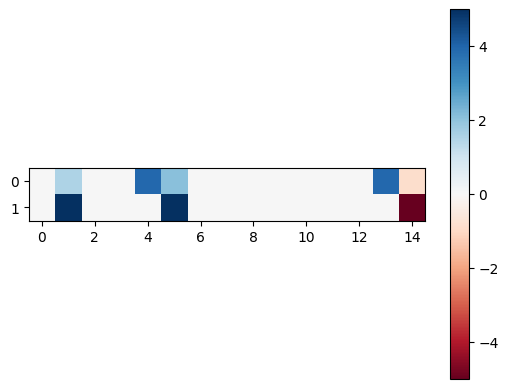

In [34]:
import matplotlib.pyplot as plt
# when things are symmetric, get more zeros in bispectrum
# chirality corresponds to first element in plt.imshow below
vmax = 5
plt.imshow(torch.stack([si_bi, fe_bi], axis=0), cmap='RdBu', vmax=vmax, vmin=-vmax)
plt.colorbar()

## Computing powder XRD pattern

In [35]:
from pymatgen.core import Structure

# This is takign just the lattice of Si which btw is FCC.
si_bravais = Structure(si_prim.lattice, si_prim.species[0:1], np.zeros([1,3]))

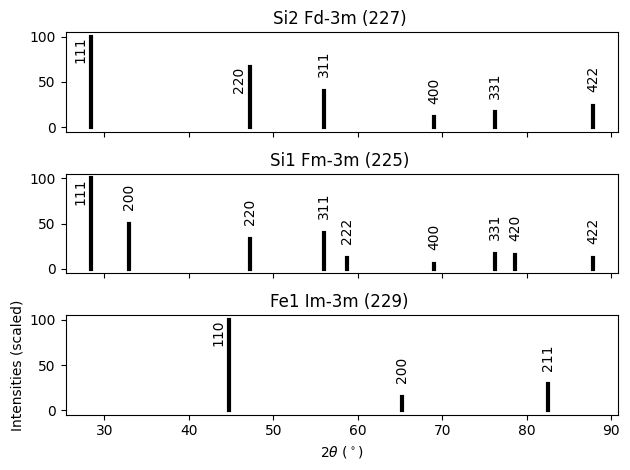

In [38]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

xrdc = XRDCalculator(wavelength='CuKa', symprec=1e-2, debye_waller_factors=None)

xrdc.plot_structures([si_prim, si_bravais, fe_prim], fontsize=10);


### Systematic absenses in diamond (two copies of fcc shifted) vs. fcc
Note how `si_lattice_pattern` has all the same peaks as `si_pattern` but `si_pattern` is missing half. 
For example, the (2,0,0) peak disappears in Si.

In [41]:
si_pattern = xrdc.get_pattern(si_prim)
si_pattern.hkls

[[{'hkl': (1, 1, 1), 'multiplicity': 8}],
 [{'hkl': (2, 2, 0), 'multiplicity': 12}],
 [{'hkl': (3, 1, 1), 'multiplicity': 24}],
 [{'hkl': (4, 0, 0), 'multiplicity': 6}],
 [{'hkl': (3, 3, 1), 'multiplicity': 24}],
 [{'hkl': (4, 2, 2), 'multiplicity': 24}]]

In [43]:
si_lattice_pattern = xrdc.get_pattern(si_bravais)
si_lattice_pattern.hkls

[[{'hkl': (1, 1, 1), 'multiplicity': 8}],
 [{'hkl': (2, 0, 0), 'multiplicity': 6}],
 [{'hkl': (2, 2, 0), 'multiplicity': 12}],
 [{'hkl': (3, 1, 1), 'multiplicity': 24}],
 [{'hkl': (2, 2, 2), 'multiplicity': 8}],
 [{'hkl': (4, 0, 0), 'multiplicity': 6}],
 [{'hkl': (3, 3, 1), 'multiplicity': 24}],
 [{'hkl': (4, 2, 0), 'multiplicity': 24}],
 [{'hkl': (4, 2, 2), 'multiplicity': 24}]]

## How to compute what we see in XRD? Need to understand the [Ewald Sphere](https://en.wikipedia.org/wiki/Ewald%27s_sphere).
But essentially, the hkl peaks + structure factors are what you need. This requires a much more in depth tutorial to go through.